# 04 · Modelado - Predicción de accidentalidad por barrio y hora

Este notebook desarrolla los puntos **4.4: Modelo no sesgado** y **4.5 — Métricas adecuadas** del taller.

Se parte de los artefactos generados en '03_feature_engineering.ipynb' (matrices ya
escaladas, imputadas y con encoding) almacenados en 'data/processed/'.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier

sys.path.append("..")

from src.utils.metrics import binary_classification_metrics, metrics_table

SEED = 42
PROCESSED_DIR = Path().resolve().parent / "data" / "processed"

# Cargar artefactos del pipeline de feature engineering
X_train = np.load(PROCESSED_DIR / "X_train.npy")
X_test  = np.load(PROCESSED_DIR / "X_test.npy")
y_train = pd.read_csv(PROCESSED_DIR / "y_train.csv").squeeze().values
y_test  = pd.read_csv(PROCESSED_DIR / "y_test.csv").squeeze().values

feature_names = pd.read_csv(PROCESSED_DIR / "feature_names.csv").squeeze().tolist()

sns.set_theme(style="whitegrid")

print(f"X_train: {X_train.shape}   y_train: {y_train.shape}")
print(f"X_test : {X_test.shape}    y_test : {y_test.shape}")
print(f"Prevalencia clase positiva — train: {y_train.mean()*100:.2f}%")
print(f"Prevalencia clase positiva — test : {y_test.mean()*100:.2f}%")

X_train: (6393424, 29)   y_train: (6393424,)
X_test : (1598356, 29)    y_test : (1598356,)
Prevalencia clase positiva — train: 1.47%
Prevalencia clase positiva — test : 1.66%


## 4.4 · Baseline ingenuo y limitación de la *accuracy*

Antes de entrenar modelos sofisticados conviene establecer un **piso de
desempeño**: ¿qué resultado obtiene un clasificador que no aprende nada?
Si un modelo elaborado no supera ese piso de forma clara, no está aportando
valor real.

Se construyen dos baselines triviales con `sklearn.dummy.DummyClassifier`:

- **`most_frequent`** — siempre predice la clase mayoritaria (0, sin accidente).
  Es el caso extremo: ignora por completo las features.
- **`stratified`** — predice de forma aleatoria según la prevalencia observada
  en el entrenamiento. Sirve como referencia probabilística.

El objetivo de este bloque es mostrar empíricamente por qué la **accuracy es
una métrica inadecuada** cuando las clases están fuertemente desbalanceadas: un
modelo que nunca predice la clase de interés puede alcanzar accuracy cercana al
99 % y, sin embargo, ser inútil en operación.

In [2]:
# Diccionario para acumular resultados
results = {}

# --- Baseline 1: clase mayoritaria ---
dummy_mf = DummyClassifier(strategy="most_frequent", random_state=SEED)
dummy_mf.fit(X_train, y_train)
y_pred_mf  = dummy_mf.predict(X_test)
y_proba_mf = dummy_mf.predict_proba(X_test)[:, 1]
results["Dummy · most_frequent"] = binary_classification_metrics(
    y_test, y_pred_mf, y_proba_mf
)

# --- Baseline 2: estratificado por prior ---
dummy_st = DummyClassifier(strategy="stratified", random_state=SEED)
dummy_st.fit(X_train, y_train)
y_pred_st  = dummy_st.predict(X_test)
y_proba_st = dummy_st.predict_proba(X_test)[:, 1]
results["Dummy · stratified"] = binary_classification_metrics(
    y_test, y_pred_st, y_proba_st
)

metrics_table(results)

,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp
Dummy · most_frequent,0.9834,0.5000,0.0000,0.0000,0.0000,0.5000,0.0166,1571808.0,0.0,26548.0,0.0
Dummy · stratified,0.9692,0.5004,0.0175,0.0155,0.0164,0.5004,0.0166,1548727.0,23081.0,26137.0,411.0


### ¿Por qué la *accuracy* no sirve aquí?

Mirando la tabla anterior:

- El baseline **`most_frequent`** alcanza una accuracy altísima (~98–99 %)
  simplemente porque la clase mayoritaria domina el dataset. Sin embargo,
  **recall = 0 y precision = 0** sobre la clase positiva: no detecta ningún
  accidente. En un escenario operativo este modelo sería completamente inútil
  — no permitiría focalizar ningún operativo ni campaña preventiva.
- El baseline **`stratified`** baja la accuracy a niveles del prior pero
  tampoco aporta señal: su PR-AUC se aproxima a la prevalencia de la clase
  positiva, que es el desempeño esperado al azar.

De aquí se desprenden tres conclusiones que orientan el resto del modelado:

1. La **accuracy oculta el fracaso** sobre la clase de interés cuando esta es
   minoritaria. No debe usarse como criterio único de selección.
2. Las métricas relevantes son las que se calculan **sobre la clase positiva**:
   precision, recall, F1 y especialmente el **PR-AUC** (Average Precision),
   que resume el desempeño en todo el rango de umbrales sin verse inflado por
   los verdaderos negativos.
3. El **ROC-AUC** del baseline es 0.5 — el piso teórico — y cualquier modelo
   debe superarlo de forma sustancial para considerarse útil. Aun así, en
   problemas tan desbalanceados como este, el **PR-AUC es más informativo**
   que el ROC-AUC.

Estas métricas guiarán la comparación de modelos en las secciones siguientes.

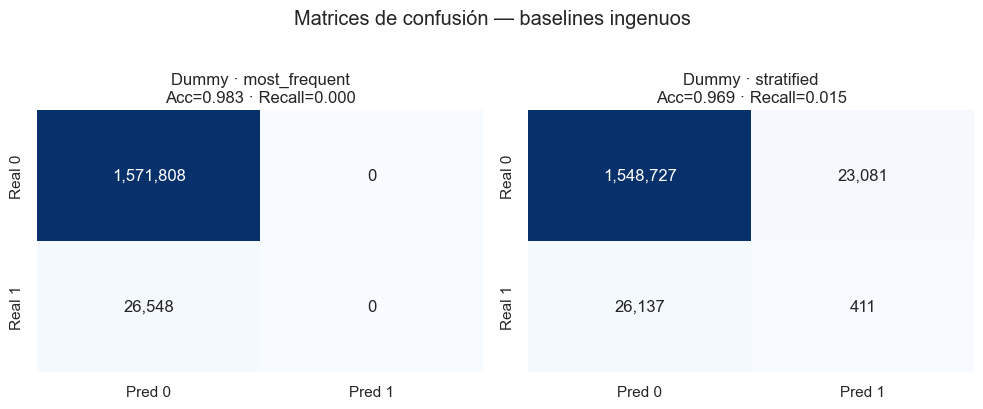

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (name, res) in zip(axes, results.items()):
    cm = np.array([[res["tn"], res["fp"]],
                   [res["fn"], res["tp"]]])
    sns.heatmap(
        cm, annot=True, fmt=",", cmap="Blues",
        xticklabels=["Pred 0", "Pred 1"],
        yticklabels=["Real 0", "Real 1"],
        cbar=False, ax=ax,
    )
    ax.set_title(f"{name}\nAcc={res['accuracy']:.3f} · Recall={res['recall']:.3f}")

plt.suptitle("Matrices de confusión — baselines ingenuos", y=1.02)
plt.tight_layout()
plt.show()